<h1>Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Data Preparation" data-toc-modified-id="Data Preparation-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Data Preparation</a></span><ul class="toc-item"><li><span><a href="#Receiving-data" data-toc-modified-id="Receiving-data-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Receiving data</a></span></li><li><span><a href="#Checking-formula" data-toc-modified-id="Checking-formula-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Checking the formula</a></span></li></ul></li><li><span><a href="#Data analysis" data-toc-modified-id="Data analysis-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Analysis data</a></span></li><li><span><a href="#Model" data-toc-modified-id="Model-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Model</a></span></li><li><span><a href="#Output" data-toc-modified-id="Output-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Output</a></span></li>

# Recovery of gold from ore

Let's prepare a prototype of a machine learning model for Digital. The company develops solutions for the efficient operation of industrial enterprises.

The model must predict the recovery rate of gold from gold ore. We use data with production and purification parameters.

The model will help optimize production so as not to launch an enterprise with unprofitable characteristics.

We need:

1. Prepare data;
2. Conduct exploratory data analysis;
3. Build and train the model.

* The objective of this research is to create a model that will help optimize production so as not to launch an enterprise with unprofitable characteristics.
* Action plan:
    * Get dataset
    * Analyze data
    * Conduct data preprocessing
    * Train models and select the best ones

## Data preparation

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

### Receiving data

In [69]:
full_data = pd.read_csv('../datasets/gold_recovery_full_new.csv')
test_data = pd.read_csv('../datasets/gold_recovery_test_new.csv')
train_data = pd.read_csv('../datasets/gold_recovery_train_new.csv')

Let's create a function to display information in more detail.

In [70]:
def data_info(data):
    data.info()
    display(data.head())
    display(data.describe())


In [71]:
data_info(full_data)
data_info(test_data)
data_info(train_data)

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,19438.000000,19438.000000,19228.000000,19439.000000,19439.000000,19438.000000,19338.000000,19433.000000,19439.000000,19415.000000,...,19433.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19437.000000,19438.000000
mean,5.168470,9.978895,9.501224,44.076513,67.050208,9.688589,2.705795,10.583728,3.042467,144.624774,...,18.987674,-485.894516,15.010366,-461.078636,15.694452,-488.684065,12.198224,-487.149827,18.959024,-505.436305
std,1.372348,1.669240,2.787537,5.129784,10.125840,2.328642,0.949077,2.868782,0.922808,44.464071,...,5.411058,47.758570,4.890228,67.405524,5.510974,34.533396,5.333024,38.347312,5.550498,37.689057
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003112,...,0.000000,-799.798523,0.000000,-800.836914,-0.372054,-797.323986,0.528083,-800.220337,-0.079426,-809.741464
25%,4.251240,9.137262,7.722820,43.402215,63.299712,8.062878,2.040119,8.938947,2.461138,114.107029,...,14.975734,-500.704892,11.940294,-500.187742,10.988606,-500.458467,8.971105,-500.129462,14.983037,-500.728067
50%,5.066094,10.102433,9.218961,45.011244,68.172738,9.743623,2.748730,10.622456,2.984909,143.232103,...,18.017481,-499.837793,14.971014,-499.459786,15.000036,-499.802605,11.019433,-499.935317,19.960541,-500.048400
75%,5.895527,11.035769,10.947813,46.275313,72.686642,11.134294,3.333216,12.104271,3.571351,175.075656,...,23.012470,-498.249730,19.034162,-400.118106,18.026190,-498.384187,14.019088,-499.436708,24.003170,-499.495378
max,16.001945,17.031899,19.615720,52.756638,100.000000,19.552149,5.804178,22.317730,8.245022,265.983123,...,30.115735,-245.239184,31.269706,-6.506986,43.709931,-244.483566,27.926001,-137.740004,32.188906,-104.427459


,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,5286.000000,5285.000000,5290.000000,5286.000000,5.290000e+03,5290.000000,5.290000e+03,5290.000000,5.290000e+03,5290.000000,...,5.290000e+03,5290.000000,5.290000e+03,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000
mean,174.839652,8.683596,7.266339,1.383803,1.539494e+03,-497.665883,1.545174e+03,-500.273098,1.527272e+03,-498.330680,...,1.632007e+01,-505.144570,1.373544e+01,-463.349858,12.804186,-501.329122,9.881145,-495.663398,17.304935,-501.793193
std,43.027080,3.072050,0.610219,0.643474,1.167979e+02,19.952431,1.222246e+02,32.968307,1.225380e+02,21.964876,...,3.493583e+00,31.427337,3.430484e+00,86.189107,3.026591,17.951495,2.868205,34.535007,4.536544,39.044215
min,2.566156,0.003839,5.650000,0.004984,5.445860e-32,-795.316337,6.647490e-32,-799.997015,4.033736e-32,-799.960571,...,1.079872e-16,-799.798523,2.489718e-17,-800.836914,0.069227,-797.323986,0.528083,-800.220337,-0.079426,-809.741464
25%,147.121401,6.489555,6.890000,0.907623,1.498936e+03,-500.357298,1.498971e+03,-500.703002,1.473230e+03,-501.018117,...,1.403618e+01,-500.868258,1.202862e+01,-500.323028,10.914838,-500.726841,8.036719,-500.194668,13.997317,-500.690984
50%,177.828489,8.052207,7.250000,1.197610,1.585129e+03,-499.969164,1.595622e+03,-500.028514,1.549595e+03,-500.017711,...,1.700847e+01,-500.115727,1.496486e+01,-499.576513,12.954182,-499.990332,10.004301,-499.990535,16.014935,-500.007126
75%,208.125438,10.027764,7.600000,1.797819,1.602077e+03,-499.568951,1.602324e+03,-499.293257,1.601144e+03,-498.994130,...,1.803862e+01,-499.404224,1.596213e+01,-400.933805,15.097528,-499.283191,11.997467,-499.719913,21.020013,-499.373018
max,265.983123,40.000000,15.500000,4.102454,2.103104e+03,-57.195404,1.813084e+03,-142.527229,1.715054e+03,-150.937035,...,3.005180e+01,-401.565212,3.126971e+01,-6.506986,25.258848,-244.483566,14.086866,-137.740004,26.705889,-123.307487


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,14148.000000,14148.000000,13938.000000,14149.000000,14149.000000,14149.000000,14049.000000,14144.000000,14149.000000,14129.000000,...,14143.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14147.000000,14148.000000
mean,5.142034,10.132960,9.202849,44.003792,66.518832,9.607035,2.597298,10.512122,2.918421,133.320659,...,19.985454,-478.696836,15.487065,-460.229416,16.775136,-483.956022,13.064590,-483.966564,19.577539,-506.798480
std,1.369586,1.654930,2.790516,4.905261,10.295402,2.319069,0.971843,3.003617,0.903712,39.431659,...,5.657723,50.736021,5.255655,58.843586,5.831906,37.892788,5.765617,39.207913,5.764417,37.079249
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003112,...,0.000000,-799.709069,0.000000,-799.889113,-0.372054,-797.142475,0.646208,-800.006180,0.195324,-809.398668
25%,4.211620,9.297355,7.484645,43.276111,62.545817,7.997429,1.905973,8.811324,2.368607,107.006651,...,14.990775,-500.628656,11.894558,-500.149000,11.083980,-500.363177,8.994405,-500.105994,14.989304,-500.745104
50%,4.994652,10.297144,8.845462,44.872436,67.432775,9.480270,2.592022,10.514621,2.851025,133.018328,...,20.001789,-499.681450,14.975536,-499.388738,17.932223,-499.702452,11.997547,-499.914556,19.984175,-500.061431
75%,5.859540,11.170603,10.487508,46.166425,72.346428,11.003707,3.241723,11.933009,3.434764,159.825396,...,24.990826,-477.472413,20.059375,-400.039008,21.346550,-487.712108,17.982903,-453.186936,24.991623,-499.536466
max,16.001945,17.031899,18.124851,52.756638,100.000000,19.552149,5.639565,22.317730,8.197408,250.127834,...,30.115735,-245.239184,24.007913,-145.071088,43.709931,-275.073125,27.926001,-157.396071,32.188906,-104.427459


Based on a preliminary inspection, we can say that there are really a lot of signs, many of them contain gaps that will have to be processed, but all the columns are given the required type, which simplifies the task a little.

### Formula checking

Let's write a formula for calculating recovery and check it.

In [72]:
def calc_recovery(fraction_gold_after_flot, fraction_gold_before_flot, fraction_gold_tails):
    return (fraction_gold_after_flot * (fraction_gold_before_flot - fraction_gold_tails) / \
           (fraction_gold_before_flot * (fraction_gold_after_flot - fraction_gold_tails))) * 100



In [73]:
display(calc_recovery(train_data['rougher.output.concentrate_au'], train_data['rougher.input.feed_au'], train_data['rougher.output.tail_au']))


0        87.107763
1        86.843261
2        86.842308
3        87.226430
4        86.688794
           ...    
14144    89.574376
14145    87.724007
14146    88.890579
14147    89.858126
14148    89.514960
Length: 14149, dtype: float64

In [74]:
func_result = calc_recovery(train_data['rougher.output.concentrate_au'], train_data['rougher.input.feed_au'], train_data['rougher.output.tail_au'])
train_data['rougher.output.recovery']

0        87.107763
1        86.843261
2        86.842308
3        87.226430
4        86.688794
           ...    
14144    89.574376
14145    87.724007
14146    88.890579
14147    89.858126
14148    89.514960
Name: rougher.output.recovery, Length: 14149, dtype: float64

At first glance, everything is identical, let’s check it more clearly.

In [75]:
mae = mean_absolute_error(y_true=train_data['rougher.output.recovery'], y_pred=func_result)
mae

9.73512347450521e-15

There is a very small difference, most likely this is due to the way Python stores and counts data, let's round everything to 6 digits and test our theory.

In [76]:
print('Number of mismatched values:', len(train_data) - ((round(train_data['rougher.output.recovery'], 6) == round(func_result, 6))).sum())

In [77]:
mae = mean_absolute_error(y_true=round(train_data['rougher.output.recovery'], 6), y_pred=round(func_result, 6))
mae

0.0

Yes, as we said earlier, the data is identical.

In [78]:
set(train_data.columns) - set(test_data.columns)

{'final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_au',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_au',
 'rougher.output.ta

In the test sample we do not have output features, since these are target features.

Also in the test there are no calculation signs for the rougher stage, apparently this data is calculated later and is not available during the process.

In [79]:
train_data.isna().sum()

date                                            0
final.output.concentrate_ag                     1
final.output.concentrate_pb                     1
final.output.concentrate_sol                  211
final.output.concentrate_au                     0
                                             ... 
secondary_cleaner.state.floatbank5_a_level      1
secondary_cleaner.state.floatbank5_b_air        1
secondary_cleaner.state.floatbank5_b_level      1
secondary_cleaner.state.floatbank6_a_air        2
secondary_cleaner.state.floatbank6_a_level      1
Length: 87, dtype: int64

There are missing values ​​in almost every column, we will correct them!

Let's look at the column with the most gaps connected to time.

In [80]:
tmp_data = pd.DataFrame([], columns=['date', 'scots'])
tmp_data['date'] = train_data[train_data['secondary_cleaner.output.tail_sol'].isna()]['date']
tmp_data['scots'] = train_data[train_data['secondary_cleaner.output.tail_sol'].isna()]['secondary_cleaner.output.tail_sol']
tmp_data

,date,scots
1616,2016-04-01 08:00:00,NaN
1617,2016-04-01 09:00:00,NaN
1618,2016-04-01 10:00:00,NaN
1619,2016-04-01 13:00:00,NaN
1826,2016-04-16 06:00:00,NaN
...,...,...
14135,2018-08-17 21:59:59,NaN
14136,2018-08-17 22:59:59,NaN
14137,2018-08-17 23:59:59,NaN
14138,2018-08-18 00:59:59,NaN


As we can see, the data is updated every hour, which means the data was not recorded either because it was not updated, or a mechanical error, however, in both cases, you can use forward fill and fill in the gaps. “It is advisable to use this method when the data is sliced ​​by time and, accordingly, by time and sorted.” - suits us!

In [81]:
full_data=full_data.fillna(method='ffill')
train_data=train_data.fillna(method='ffill')

In [82]:
train_data.isna().sum()

date                                          0
final.output.concentrate_ag                   0
final.output.concentrate_pb                   0
final.output.concentrate_sol                  0
final.output.concentrate_au                   0
                                             ..
secondary_cleaner.state.floatbank5_a_level    0
secondary_cleaner.state.floatbank5_b_air      0
secondary_cleaner.state.floatbank5_b_level    0
secondary_cleaner.state.floatbank6_a_air      0
secondary_cleaner.state.floatbank6_a_level    0
Length: 87, dtype: int64

Everything is clean, the gaps are gone!

## Data analysis

Let's see how the concentration of metals changes at different stages of purification.

In [83]:
rougher_ag = train_data["rougher.output.concentrate_ag"]
rougher_au = train_data["rougher.output.concentrate_au"]
rougher_pb = train_data["rougher.output.concentrate_pb"]

primary_ag = train_data["primary_cleaner.output.concentrate_ag"]
primary_au = train_data["primary_cleaner.output.concentrate_au"]
primary_pb = train_data["primary_cleaner.output.concentrate_pb"]

secondary_ag = train_data["final.output.concentrate_ag"]
secondary_au = train_data["final.output.concentrate_au"]
secondary_pb = train_data["final.output.concentrate_pb"]

Let's make our life easier and create a function.

In [84]:
def plotting_hist(data, metal, color):
    data.plot(kind='hist', bins=30, figsize=(10, 5), color=color, alpha=0.3, label=metal);
    plt.legend()

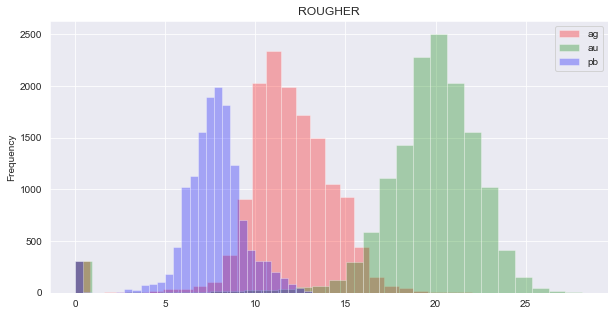

In [85]:
plt.title("ROUGHER")
plotting_hist(rougher_ag,'ag' , 'red')
plotting_hist(rougher_au, 'au', 'green')
plotting_hist(rougher_pb, 'pb', 'blue')
plt.show()

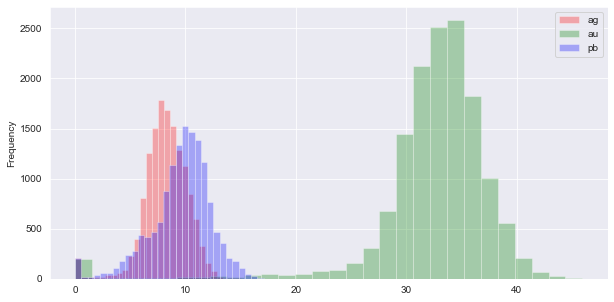

In [86]:
plotting_hist(primary_ag,'ag' , 'red')
plotting_hist(primary_au,'au' , 'green')
plotting_hist(primary_pb,'pb' , 'blue')

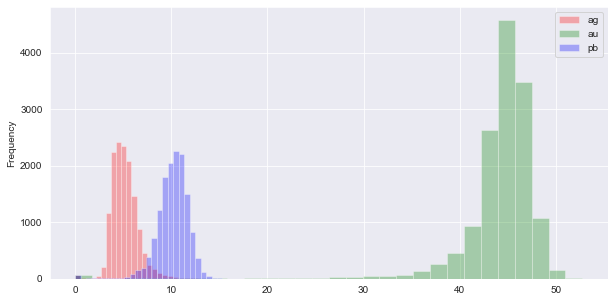

In [87]:
plotting_hist(secondary_ag,'ag' , 'red')
plotting_hist(secondary_au,'au' , 'green')
plotting_hist(secondary_pb,'pb' , 'blue')


You can easily notice a trend - with subsequent stages of processing, the concentration rises further and with each stage shows better and better values, unlike silver and tin. Silver, for example, only worsens its performance, and the concentration of tin remains virtually unchanged.

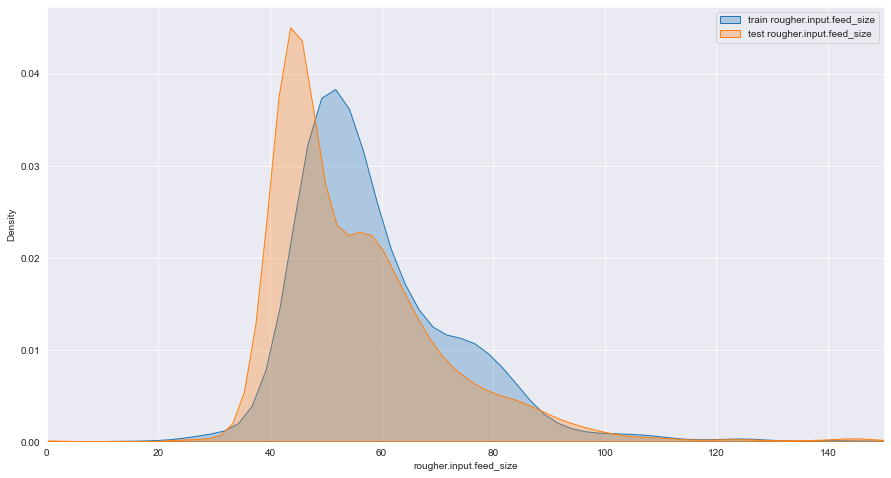

In [88]:
sns.kdeplot(train_data['rougher.input.feed_size'], label='train rougher.input.feed_size', alpha=0.3, shade=True);
sns.kdeplot(test_data['rougher.input.feed_size'], label='test rougher.input.feed_size', alpha=0.3, shade=True);
plt.xlim(0, 150);
plt.gcf().set_size_inches(15, 8)
plt.legend()
plt.show()

At first glance, the distributions are quite close, although they do not coincide perfectly. This means we can conclude that the estimates of the models on the two sets will be comparable.

Let's collect all the necessary data together.

In [89]:
train_data['sum_concentrate_rougher']=train_data['rougher.output.concentrate_ag']+train_data['rougher.output.concentrate_pb']+train_data['rougher.output.concentrate_sol']+train_data['rougher.output.concentrate_au']


train_data['sum_primary_cleaner_output_concentrate']=train_data['primary_cleaner.output.concentrate_ag']+train_data['primary_cleaner.output.concentrate_pb']+train_data['primary_cleaner.output.concentrate_sol']+train_data['primary_cleaner.output.concentrate_au']


train_data['sum_final_output_concentrate']=train_data['final.output.concentrate_ag']+train_data['final.output.concentrate_pb']+train_data['final.output.concentrate_sol']+train_data['final.output.concentrate_au']



In [90]:
sns.kdeplot(train_data['sum_concentrate_rougher'], label='sum_concentrate_rougher', alpha=0.3, shade=True);
plt.legend()
sns.kdeplot(train_data['sum_primary_cleaner_output_concentrate'], label='sum_primary_cleaner_output_concentrate', alpha=0.3, shade=True);
plt.legend()
sns.kdeplot(train_data['sum_final_output_concentrate'], label='sum_final_output_concentrate', alpha=0.3, shade=True);
plt.legend()
plt.title('Total metal concentration at rougher, primary cleaner, and final stages');
plt.gcf().set_size_inches(15, 8)


In general, as it should be, the concentration increases with each stage.

There are outliers - the distribution shows that there are outliers. There are many values ​​from 0 to 40 that can be removed. There are a lot of them, but their purity is zero. Therefore, I think we can remove them so as not to interfere with model training.

In [91]:
train_data=train_data[train_data['sum_final_output_concentrate']>40]
train_data=train_data[train_data['sum_primary_cleaner_output_concentrate']>40]
train_data=train_data[train_data['sum_concentrate_rougher']>40]
train_data.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level,sum_concentrate_rougher,sum_primary_cleaner_output_concentrate,sum_final_output_concentrate
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980,66.424950,72.640924,63.644396
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184,67.012710,72.543485,63.957723
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363,66.103793,72.095042,64.311180
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129,65.752751,59.957723,63.573449
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691,65.908382,71.321010,64.004667


## Model

Let's implement the sMAPE metric function.

In [92]:
def smape (predict, target):
    smape = abs(target-predict)/((abs(target)+abs(predict))/2)*100
    smape=smape.fillna(value=0)
    smape = sum(smape)/len(smape)
    return smape

And also the scorer function, we will need it for cross-validation.

In [93]:
def sMape_scorer(model, features, target):
    pred = model.predict(features)
    sMAPE_ = smape(target, pred)
    return sMAPE_


First of all, we will look for the best model for the target feature - rougher.output.recovery. Let's check it on a tree, forest and linear regression.

In [94]:
rougher_columns = [c for c in test_data.columns if "rougher" in c]  # Use only rougher features
x_rougher = train_data[rougher_columns]
y_rougher = train_data['rougher.output.recovery']

In [95]:
rfc = DecisionTreeRegressor(random_state=12345)

parametrs = {'max_depth': range(1, 11, 2)}  # depth

grid = GridSearchCV(rfc, parametrs, cv=5, scoring=make_scorer(smape, greater_is_better=False))
grid.fit(x_rougher, y_rougher)

print('Best parameters:', grid.best_params_, '\n')
print('Best score:', grid.best_score_, '\n')


The best score is negative since we specified the parameter greater_is_better=False.

Best parameters: {'max_depth': 5, 'n_estimators': 20}

Best score: -6.2811622171682995

CPU times: total: 2min 22s
Wall time: 2min 22s

In [96]:
%%time
# Best parameters: {'max_depth': 5, 'n_estimators': 20}
rougher_columns = [c for c in test_data.columns if "rougher" in c] # Use only rougher features
x_rougher = train_data[rougher_columns]
y_rougher = train_data['rougher.output.recovery']

rfc = RandomForestRegressor(random_state=12345)

parametrs = { 'n_estimators': range (10, 41, 10), # number of trees in the forest
              'max_depth': range (1,11, 2)} # depth

grid = GridSearchCV(rfc, parametrs, cv=5, scoring=make_scorer(smape, greater_is_better=False))
grid.fit(x_rougher, y_rougher)

print('Best parameters:', grid.best_params_, '\n')
print('Best score:', grid.best_score_, '\n')

Since there is no validation sample, and linear regression does not have hyperparameters, at least those that we know about, we will have to manually split and calculate the metric.

In [97]:
from sklearn.model_selection import train_test_split

features_train_r, features_valid_r, target_train_r, target_valid_r = train_test_split(
    x_rougher, y_rougher, test_size=0.25, random_state=12345)

model = LinearRegression()
model.fit(features_train_r, target_train_r)
predictions_valid_r = model.predict(features_valid_r)

scores = cross_val_score(model, x_rougher, y_rougher, cv=5, scoring=make_scorer(smape))

final_score = sum(scores)/len(scores)

print(final_score)

Let's carry out similar actions for the second target feature - final.output.recovery.

In [98]:
final_columns = [c for c in test_data.columns]
x_final = train_data[final_columns].drop('date', axis=1)

y_final = train_data['final.output.recovery']


In [99]:
rfc = DecisionTreeRegressor(random_state=12345)

parametrs = {'max_depth': range(1, 11, 2)}  # depth

grid = GridSearchCV(rfc, parametrs, cv=5, scoring=make_scorer(smape, greater_is_better=False))
grid.fit(x_final, y_final)

print('Best parameters:', grid.best_params_, '\n')
print('Best score:', grid.best_score_, '\n')


Best parameters: {'max_depth': 3, 'n_estimators': 20}

Best score: -8.741313112761201

CPU times: total: 5min 33s
Wall time: 5min 33s

In [100]:
%%time
# Best parameters: {'max_depth': 3, 'n_estimators': 20}
rfc = RandomForestRegressor(random_state=12345)

parametrs = { 'n_estimators': range (10, 41, 10), # number of trees in the forest
              'max_depth': range (1,11, 2)} # depth

grid = GridSearchCV(rfc, parametrs, cv=5, scoring=make_scorer(smape, greater_is_better=False))
grid.fit(x_final, y_final)

print('Best parameters:', grid.best_params_, '\n')
print('Best score:', grid.best_score_, '\n')

In [101]:
from sklearn.model_selection import train_test_split

features_train_f, features_valid_f, target_train_f, target_valid_f = train_test_split(
    x_final, y_final, test_size=0.25, random_state=12345)

model = LinearRegression()
model.fit(features_train_f, target_train_f)
predictions_valid_f = model.predict(features_valid_f)

scores = cross_val_score(model, x_final, y_final, cv=5, scoring=make_scorer(smape))

final_score = sum(scores)/len(scores)

print(final_score)

Thus, for both target features, the best model turned out to be a random forest, albeit with different hyperparameters.

Let's calculate the final sMAPE.

In [102]:
data_test = pd.merge(test_data, full_data[['date', 'rougher.output.recovery']], on='date')
data_test = data_test.fillna(method='ffill')

In [103]:
rougher_columns = [c for c in data_test.columns if "rougher" in c]
x_rougher_features = data_test[rougher_columns].drop('rougher.output.recovery', axis=1)


In [104]:
best_model_rougher = RandomForestRegressor(random_state=12345, max_depth=5, n_estimators=20)
best_model_rougher.fit(x_rougher, y_rougher)
predicted_rough = best_model_rougher.predict(x_rougher_features)
smape_rougher = smape(predicted_rough, data_test['rougher.output.recovery'])

In [105]:
data_test = pd.merge(test_data, full_data[['date', 'final.output.recovery']], on='date')
data_test = data_test.fillna(method='ffill')
x_final_features = data_test.drop(['final.output.recovery', 'date'], axis=1)


In [106]:
best_model_final = RandomForestRegressor(random_state=12345, max_depth=3, n_estimators=20)
best_model_final.fit(x_final, y_final)
predicted_final = best_model_final.predict(x_final_features)
smape_final = smape(predicted_final, data_test['final.output.recovery'])

In [107]:
0.25 * smape_rougher + 0.75 * smape_final

9.143445584037108

The final sMAPE is 9.14! Pretty close to zero.

## Conclusion

In this project, a lot of work was done with data. They were obtained from three csv files. After the examination, primary conclusions were made. The calculation formula rougher.output.recovery was implemented and tested successfully. It was discovered which features were missing in the test sample and why. There were also a lot of gaps in the signs, but after making small conclusions, they were all filled using the forward fill method, since the data was recorded every hour. There were distributions constructed in which it was possible to see that the concentration of gold increased with each stage, in contrast to silver and tin. The distribution of raw material granules turned out to be the same, so this did not interfere with the evaluation of the model. We also looked at the total concentration of all substances at different stages of processing, and as expected, it increased with each stage. We implemented the *sMAPE* metric function, evaluated 6 models using cross-validation and selected the best hyperparameters. The random forest showed its best performance, and we used it to calculate the final *sMAPE*, it is equal to 9.14, which is quite acceptable!